In [1]:
import spectral
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import os
import shutil

In [2]:
import numpy as np
print(np.__version__)


1.24.1


## Move files and get RGB

In [6]:
def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    normalized = (image - min_val) / (max_val - min_val)
    return normalized

In [3]:
def get_hyp_rgb(image, wavelengths, save_path):
    
    # image = image.load()  # Convert to numpy array
    
    try:
        image = image.load()
    except AttributeError:
        if not isinstance(image, np.ndarray):
            raise ValueError("Input image is neither a recognized format with a load() method nor a numpy array.")
    
    # # Find global minimum and maximum across all bands
    # global_min = np.min(image_array)
    # global_max = np.max(image_array)
    # Find the bands closest to red, green, and blue wavelengths
    red_band_index = find_nearest_band(wavelengths, 660)
    green_band_index = find_nearest_band(wavelengths, 550)
    blue_band_index = find_nearest_band(wavelengths, 450)
    
    
#         # Find global minimum and maximum across all bands
#     global_min = np.min(image)
#     global_max = np.max(image)
    
#     print(global_min)
#     print(global_max)

#     # Normalize the entire 3D image using the global min and max
#     image_normalized = (image - global_min) / (global_max - global_min)

#     # Extract the RGB bands from the normalized image
#     red_normalized = image_normalized[:, :, [red_band_index]]
#     green_normalized = image_normalized[:, :, [green_band_index]]
#     blue_normalized = image_normalized[:, :, [blue_band_index]]


    # Extract the RGB bands
    red_band = image[:, :, [red_band_index]]
    green_band = image[:, :, [green_band_index]]
    blue_band = image[:, :, [blue_band_index]]

    # print(red_band.min())
    # print(red_band.max())
    # Normalize the bands to the range [0, 1]
    red_normalized = normalize_image(red_band)
    green_normalized = normalize_image(green_band)
    blue_normalized = normalize_image(blue_band)
    
    

    # Stack the normalized bands to create an RGB image
    rgb_image = np.stack((red_normalized, green_normalized, blue_normalized), axis=-1)
    
    # rgb_image = np.stack((red_band, green_band, blue_band), axis=-1)

    # Squeeze any extra dimensions
    rgb_image_squeezed = np.squeeze(rgb_image)
    

    # Convert the RGB image to the range [0, 255] and save it as a PNG file
    rgb_image_uint8 = (rgb_image_squeezed * 255).astype(np.uint8)

    rgb_image_uint8 = cv2.cvtColor(rgb_image_uint8, cv2.COLOR_RGB2BGR)
    try:
        output_path =save_path[:-4]+".png"
        cv2.imwrite(output_path, rgb_image_uint8)
        print(f"Image saved as {output_path}")
    except Exception as e:
        print("Error saving the image:", e)

#     # Display the RGB image
#     import matplotlib.pyplot as plt

    plt.imshow(rgb_image_squeezed)
    plt.show()

In [4]:
def find_nearest_band(wavelengths, target_wavelength):
    wavelengths_float = np.array([float(w) for w in wavelengths])
    return np.argmin(np.abs(wavelengths_float - target_wavelength))


# the move_files function moves all additional files to other_ff
def move_files(root_path):

    all_files = os.listdir(root_path)
    
    output_folder = os.path.join(root_path, 'other_ff')
    if os.path.exists(output_folder):
        all_files.remove('other_ff')

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for file in all_files:
        if file.endswith(".hdr") or file.endswith(".bil") or file.endswith(".png"):
            continue

        source_path = os.path.join(root_path, file)
        destination_path = os.path.join(output_folder, file)
        shutil.move(source_path, destination_path)

Image saved as D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\003-specim-fx10.png


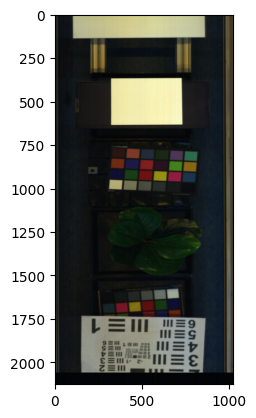

Image saved as D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\004-specim-fx10.png


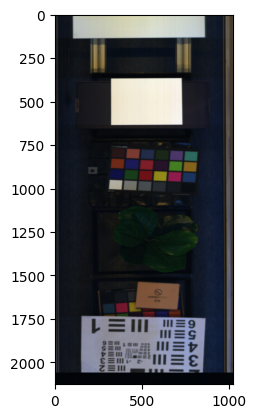

Image saved as D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\005-specim-fx10.png


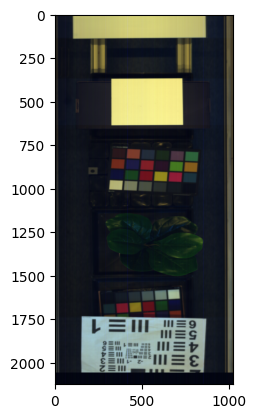

Image saved as D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\006-specim-fx10.png


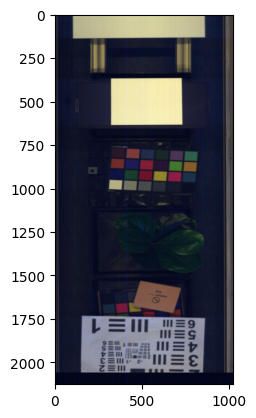

In [7]:
dest_dir = r"D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl"
root_path = dest_dir
# move_files(root_path)
all_files = os.listdir(dest_dir)
for file in all_files:
    if file.endswith(".hdr"):
        header_file = os.path.join(root_path,file)
        if (os.path.isfile(header_file[:-4]+".png")):
            continue
        image = spectral.open_image(header_file)
        wavelengths = image.metadata['wavelength']
        get_hyp_rgb(image, wavelengths, header_file)

In [5]:
def select_coor(img, save_name):
    white_calib_coor = []
    drawing = False
    start_x, start_y = -1, -1
    img_original = img.copy()

    # Function to display the coordinates and draw rectangles
    def click_event(event, x, y, flags, params):
        nonlocal drawing, start_x, start_y, white_calib_coor, img, img_original

        if event == cv2.EVENT_LBUTTONDOWN:
            drawing = True
            start_x, start_y = x, y

        elif event == cv2.EVENT_MOUSEMOVE:
            if drawing:
                img_copy = img.copy()
                cv2.rectangle(img_copy, (start_x, start_y), (x, y), (255, 0, 0), 2)
                cv2.imshow('image', img_copy)

        elif event == cv2.EVENT_LBUTTONUP:
            drawing = False
            end_x, end_y = x, y
            cv2.rectangle(img, (start_x, start_y), (end_x, end_y), (255, 0, 0), 2)
            cv2.imshow('image', img)
            print("Start:", start_x, start_y, "End:", end_x, end_y)

            # Store all four coordinates of the selected rectangle
            top_left = (start_x, start_y)
            top_right = (end_x, start_y)
            bottom_left = (start_x, end_y)
            bottom_right = (end_x, end_y)
            white_calib_coor.append([top_left, top_right, bottom_right, bottom_left])

            # Save the selected rectangle as a separate image without the blue lines
            roi = img_original[start_y:end_y, start_x:end_x]
            cv2.imwrite('./coordinates/' + save_name+'.png', roi)

    # def update_display(*args):
    #     nonlocal img, img_original
    #     x_offset = cv2.getTrackbarPos('Horizontal', 'image')
    #     y_offset = cv2.getTrackbarPos('Vertical', 'image')
    #     img = img_original[y_offset:y_offset + window_height, x_offset:x_offset + window_width]
    #     cv2.imshow('image', img)

    window_width, window_height = 800, 600
    cv2.namedWindow('image', cv2.WINDOW_NORMAL)
    cv2.resizeWindow('image', window_width, window_height)

    # img_height, img_width, _ = img_original.shape
    # cv2.createTrackbar('Horizontal', 'image', 0, img_width - window_width, update_display)
    # cv2.createTrackbar('Vertical', 'image', 0, img_height - window_height, update_display)

    # Displaying the image
    cv2.imshow('image', img)

    # Setting mouse handler for the image and calling the click_event() function
    cv2.setMouseCallback('image', click_event)

    # Wait for a key to be pressed to exit
    cv2.waitKey(0)

    # Close the window
    cv2.destroyAllWindows()

    print(white_calib_coor)
    # os.makedirs('./data/coordinates_test', exist_ok=True)
    # Derive the save path from the img_path
    save_path = os.path.splitext(img_path)[0]+'_'+save_name + '.npy'
    
    with open(save_path, 'wb') as f:
        np.save(f, white_calib_coor)

    print(f"Coordinates saved to: {save_path}")


In [11]:
# Reading the image
img_path = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10.png'
img = cv2.imread(img_path, 1)
select_coor(img, 'white_calib')


Start: 116 28 End: 851 96
[[(116, 28), (851, 28), (851, 96), (116, 96)]]
Coordinates saved to: D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10_white_calib.npy


In [13]:
# Reading the image
img_path = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10.png'
img = cv2.imread(img_path, 1)
select_coor(img, 'dark_calib')


Start: 134 2072 End: 858 2112
[[(134, 2072), (858, 2072), (858, 2112), (134, 2112)]]
Coordinates saved to: D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10_dark_calib.npy


In [6]:
def get_rois():
    # Loading the saved dark calibration and white calibration coordinates
    dc = np.load(r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10_dark_calib.npy')
    wc = np.load(r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10_white_calib.npy')

    # Constructing the new, larger rectangle
    big_rect = np.array([[
        [wc[0][0][0], wc[0][0][1]],    # Top-left corner
        [wc[0][1][0], wc[0][1][1]],    # Top-right corner
        [wc[0][3][0], dc[0][3][1]],     # Bottom-left corner
        [wc[0][2][0], dc[0][3][1]]    # Bottom-right corner
    ]])
    

#     # print(big_rect)


#     # Reading the image
#     img_path = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\hyperspec_calib\003-specim-fx10.png'
#     img = cv2.imread(img_path, 1)

#     # Cropping the image
#     top_left = big_rect[0][0]
#     bottom_right = big_rect[0][3]
#     cropped_img = img[top_left[1]:bottom_right[1], top_left[0]:bottom_right[0]]


#     # Deriving the save_path from img_path
#     save_path = img_path.replace(".png", "_crop.png")

#     # Saving the cropped image to the derived save_path
#     cv2.imwrite(save_path, cropped_img)

    return dc, wc, big_rect

In [ ]:
header_file = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10.hdr'
print(header_file)
image = spectral.open_image(header_file)
print(np.shape(image))
dc, wc, big_rect = get_rois()

In [19]:
print(big_rect)

[[[ 116   28]
  [ 851   28]
  [ 116 2112]
  [ 851 2112]]]


In [ ]:

header_file = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10.hdr'
print(header_file)
image = spectral.open_image(header_file)
print(np.shape(image))
dc, wc, big_rect = get_rois()

In [26]:
import numpy as np
import spectral

# Open the image
header_file = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\003-specim-fx10.hdr'
image = spectral.open_image(header_file)
wavelengths = image.metadata['wavelength']
# Define the rectangle's coordinates
big_rect = np.array([[[ 149, 36],
                      [ 825, 36],
                      [ 149, 2112],
                      [ 825, 2112]]])

# Extract the range for rows and columns
rows_range = (big_rect[0,0,1], big_rect[0,2,1])
cols_range = (big_rect[0,0,0], big_rect[0,1,0])

# Crop the image for all bands
cropped_image = image[rows_range[0]:rows_range[1], cols_range[0]:cols_range[1], :]

print(np.shape(cropped_image))


(2076, 676, 224)


In [27]:
type(image)

spectral.io.bilfile.BilFile

In [28]:
type(cropped_image)

numpy.ndarray

Image saved as D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\003-specim-fx10_cr.png


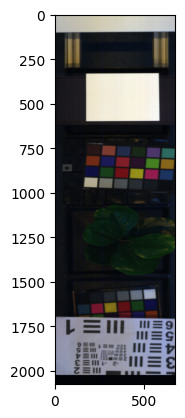

In [29]:
get_hyp_rgb(cropped_image, wavelengths, r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\003-specim-fx10_cr.hdr')

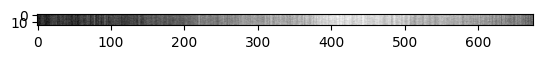

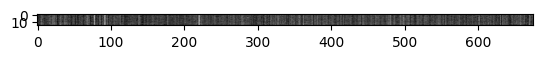

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming cropped_image is already defined and has shape (2076, 676, 224)

# Defining coordinates
white_coordinates = np.array([(0, 25), (676, 25), (0, 40), (676, 40)])
dark_coordinates = np.array([(0, 2040), (676, 2040), (0, 2055), (676, 2055)])

def extract_and_replicate(image, coordinates, target_shape):
    rows_range = (coordinates[0, 1], coordinates[2, 1])
    cols_range = (coordinates[0, 0], coordinates[1, 0])
    
    # Extracting the region
    region = image[rows_range[0]:rows_range[1], cols_range[0]:cols_range[1], :]
    
    # Displaying extracted region (for one band, e.g., the 50th band)
    plt.imshow(region[:, :, 50], cmap='gray')
    plt.show()
    
    # Replicating the region
    num_repeats = target_shape[0] // (rows_range[1] - rows_range[0])
    replicated = np.concatenate([region] * num_repeats, axis=0)
    
    # If the replicated image is shorter than the target, add additional copies
    if replicated.shape[0] < target_shape[0]:
        additional_repeats = target_shape[0] - replicated.shape[0]
        last_piece = region[:additional_repeats, :, :]
        replicated = np.concatenate([replicated, last_piece], axis=0)
        
    return replicated

# Extracting and replicating
image_shape = np.shape(cropped_image)
replicated_white_image = extract_and_replicate(cropped_image, white_coordinates, image_shape)
replicated_dark_image = extract_and_replicate(cropped_image, dark_coordinates, image_shape)

# Calibrate the image
calibrated_image = (cropped_image - replicated_dark_image) / (replicated_white_image - replicated_dark_image)
#  + 1e-10
# Check for any NaN or Inf values in the calibrated image
if np.any(np.isnan(calibrated_image)) or np.any(np.isinf(calibrated_image)):
    print("Warning: The calibrated image contains NaN or Inf values")


In [31]:
def clip_image(image):
    """
    Clips input data to the valid range:
    - [0..1] for floats
    - [0..255] for integers
    """
    if image.dtype.kind == 'f':
        return np.clip(image, 0.0, 1.0)
    elif image.dtype.kind in ('i', 'u'):
        return np.clip(image, 0, 255)
    else:
        raise ValueError("Unsupported data type")

In [32]:
norm_cal_img = clip_image(calibrated_image)

Image saved as D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\003-specim-fx10_cr_cal_nor.png


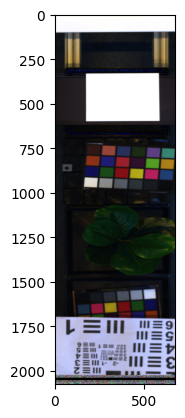

In [33]:
get_hyp_rgb(norm_cal_img, wavelengths, r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20231017_CSIRO_hll_lll_hnl_lnl\003-specim-fx10_cr_cal_nor.hdr')

In [64]:
# Reading the image
img_path = r'D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10_cr.png'
img = cv2.imread(img_path, 1)
select_coor(img, 'white_calib_cr')
 

Start: 2 28 End: 676 59
[[(2, 28), (676, 28), (676, 59), (2, 59)]]
Coordinates saved to: D:\Projects\AnacondaFiles\APPF_codes\APPF_DATA\20230927_CSIRO_calib_full_our_board\002-specim-fx10_cr_white_calib_cr.npy


In [42]:
import math

def distance(p1, p2):
    '''Calculate the Euclidean distance between two points'''
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def is_rectangle(A, B, C, D):
    '''Check if four points form a rectangle'''

    # Calculate distances
    AB = distance(A, B)
    BC = distance(B, C)
    CD = distance(C, D)
    AD = distance(D, A)
    BD = distance(B, D)
    
    print('AB: ',AB)
    print('BC: ',BC)
    print('AD: ',AD)
    print('CD: ',CD)
    print((AB**2 + AD**2))
    print( BD**2)
    # Tolerance value for floating-point comparison
    tolerance = 1e-9
    
    # Check opposite sides and use Pythagorean theorem
    if AB == CD and AD == BC and abs((AB**2 + AD**2) - BD**2) < tolerance:
        return True
    return False

# Test
A = (116, 2112)
B = (851, 2112)
C = (851, 28)
D = (116, 28)

print(is_rectangle(A, B, C, D)) # Should return True


AB:  735.0
BC:  2084.0
AD:  2084.0
CD:  735.0
4883281.0
4883281.000000001
True


In [ ]:
[[[ 116   28] #TL
  [ 851   28] #tr
  [ 116 2112] #bl
  [ 851 2112]]] #br